---
title: 'Ray Core · CPU：从读取记录到有状态任务'
---


# Ray Core：让一个读取记录的程序逐步长大

假设你要读取八条记录，每条记录都要等一会儿才能拿到。普通 Python 循环会读完一条再读下一条；但这些读取互不依赖，等待本来可以重叠。我们就从这个小问题开始，逐步把同一个程序交给 Ray，再让读取结果流向后续处理，最后给程序加上跨调用保留的计数状态。

本页改编自 Max Pumperla、Edward Oakes、Richard Liaw 的 [《Learning Ray》公开版第 2 章](https://maxpumperla.com/learning_ray/ch_02_ray_core/)，覆盖 **A Ray Core Intro** 中的连续案例。

你只需要先会写 Python 函数、循环和简单的类。装饰器、进程与异步返回会在需要时解释；无需先学完整的分布式系统。入门结束时，你应能把一个普通函数改成远程任务，说明哪里提交、哪里等待，并判断何时需要用 Actor 保留状态。

[主题入口](README.md) · [后续：GPU 资源与计算](gpu.ipynb)

## 阅读与运行准备

可以先通读讲解。本次验证使用服务器已有的 Python 3.13.5 环境；首次准备环境时，可在服务器仓库根目录按下面的 Python 3.11 示例创建：

```bash
python3.11 -m venv .venv-ray
.venv-ray/bin/python -m pip install -r topics/distributed-runtime/ray/requirements.txt
.venv-ray/bin/python -m ipykernel install --user --name ai-infra-ray --display-name "AI Infra · Ray CPU"
```

在 VS Code Remote SSH 或 JupyterLab 中选这个 kernel，并将工作目录设为本文件所在的 `topics/distributed-runtime/ray/`。VS Code 已配置 `${fileDirname}`。从一个新 kernel 开始，按顺序运行；不要在已有工作的 Ray 连接上重复初始化。本页只使用 CPU，不需要 CUDA 或 PyTorch。

正文先给示范，再按“题目 → TODO 代码 → 测试”安排练习。填写并运行你的实现后，继续运行测试；测试通过后再进入下一节。未完成的函数会抛出 NotImplementedError，因此直接“全部运行”会停在第一道未完成练习，这是预期行为。修改代码后要重新运行实现单元，避免测试仍调用 kernel 中的旧定义。

后面的示范不依赖你的练习变量。若暂时只想阅读或运行示范，可以跳过整组练习，但这不表示练习通过。测试只验证列出的可观察行为；提交时机、是否按要求使用 Actor、资源清理和机制解释仍需对照自己的代码检查。可选的背压与 Actor 并发放在入门之后。


## 1 · 先让普通 Python 程序完成工作

我们需要的数据很小，用一个列表模拟数据库即可。`database[3]` 取出第 4 个词；真正数据库涉及的连接、查询语言和网络暂时都不需要。函数 `retrieve(item)` 接受一个位置，返回 `(位置, 词)`。保留位置，是为了在后面同时发起许多读取时，仍然能认出每份结果属于哪个输入。

唯一特殊的操作是 `time.sleep(item / 10)`：它让当前执行线程等待若干秒，模拟读取的耗时。例如位置 3 对应 0.3 秒。**这些是教学参数，等待不代表 CPU 正在计算。** 下面先读一条记录，确认输入和输出是什么，再谈同时读取。


In [2]:
import time

database = [
    "Learning", "Ray", "Flexible", "Distributed",
    "Python", "for", "Machine", "Learning",
]

def retrieve(item):
    time.sleep(item / 10)       # 模拟读取等待；单位为秒。
    return item, database[item] # 把位置和对应的词一起返回。

one_record = retrieve(3)        # 普通调用在返回记录之前，不会执行下一行。
print(one_record)
assert one_record == (3, "Distributed")


(3, 'Distributed')


### 为什么八次等待会累积

现在遍历八个位置。执行 `retrieve(0)` 时，循环要等这次调用返回，才会继续 `retrieve(1)`。这一过程一直重复到位置 7，所以各次等待没有重叠。我们甚至不需要讨论操作系统调度，就能从这个程序的控制流判断这一点。

仅把教学等待相加，得到 `(0 + 1 + … + 7) / 10 = 2.8` 秒。这是忽略其他开销的模型；实际用时由下面的计时产生。`time.perf_counter()` 读取适合测量间隔的时钟，前后相减得到经过的秒数。


In [3]:
started = time.perf_counter()
sequential_data = []
for item in range(len(database)):
    record = retrieve(item)     # 本次读取返回之后，才会继续下一轮。
    sequential_data.append(record)
sequential_elapsed = time.perf_counter() - started

print("读取结果：", sequential_data)
print("本次经过秒数：", sequential_elapsed)
assert sequential_data == list(enumerate(database))


读取结果： [(0, 'Learning'), (1, 'Ray'), (2, 'Flexible'), (3, 'Distributed'), (4, 'Python'), (5, 'for'), (6, 'Machine'), (7, 'Learning')]
本次经过秒数： 2.800870188999397


把上面的循环写成 `[retrieve(i) for i in range(len(database))]`，仍然会逐次等待。列表推导式改变的是写法，没有要求 Python 同时运行这些调用。这也是本页对原文的一处修正：**这里的串行来自调用顺序，不能归因于 GIL。** GIL 是部分 Python 解释器中的线程执行约束；此处根本没有创建多个并发调用，暂时无需借助它解释现象。


### 练习 1：只读指定位置

实现 `read_selected(items)`：`items` 是有效位置组成的列表，调用已定义的普通函数 `retrieve` 逐项读取，返回记录列表。保留输入顺序和重复位置；空输入返回空列表。例如输入 `[1, 3, 5]` 时，结果应由这三个位置的记录组成。

在下面的 **TODO 单元**填写函数体，然后运行紧接的测试单元。测试会直接调用你的函数；尚未完成时，`NotImplementedError` 会提示你继续实现。先算出这三个位置的教学等待之和，再用自己的计时与之比较，说明为什么实际用时不一定等于它。

下面连续两个代码单元：**第一个是你填写的代码框，第二个是测试代码框**。改完实现后，先运行第一个，再运行第二个。


In [4]:
# 练习 1｜填写代码：在下面的 TODO 处实现

def read_selected(items):
    return [retrieve(item) for item in items]


In [5]:
# 练习 1｜测试代码：完成并运行上一个代码单元后，运行本单元

# 测试：直接调用你填写的函数，不使用前面示范的输出。
for items, expected in [
    ([1, 3, 5], [(1, "Ray"), (3, "Distributed"), (5, "for")]),
    ([5, 1], [(5, "for"), (1, "Ray")]),
    ([1, 1], [(1, "Ray"), (1, "Ray")]),
    ([], []),
]:
    actual = read_selected(items)
    assert actual == expected, f"输入 {items}：应得到 {expected}，实际为 {actual}"
print("练习 1 测试通过：读取结果、输入顺序、重复位置和空输入均正确。")


练习 1 测试通过：读取结果、输入顺序、重复位置和空输入均正确。


到这里我们已经有一个正确程序。接下来的改变只针对执行方式：某条记录还在等待时，能不能先让另一条也开始读取？


(ray-cpu-tasks)=
## 2 · 把提交工作与取得结果分开

如果仍然调用普通的 `retrieve(3)`，当前程序就会停在这次调用里。要让多个读取有机会重叠，我们需要先把“请读取这条记录”交出去，并允许当前程序继续往下走。

Ray 能让其他 Python **进程**执行函数。一个进程可以先理解为一次独立运行的 Python 程序，有自己的变量和执行位置。本 Notebook 所在的进程负责发起工作，Ray 启动的工作进程负责执行被交出去的函数。文档分别把它们称为 **driver** 和 **worker**；在本页，这两个词只用于区分“发起调用的一方”和“实际执行的一方”。“远程”并不要求另一台机器，同一服务器的不同进程也适用。

先初始化本次运行时。`num_cpus=4` 给调度器设置 4 份逻辑 CPU 资源；本页每个普通任务声明使用 1 份，便于观察多个任务。它不是把进程绑定到四个物理核心。更详细的资源规则留到有需要时再查。


In [6]:
import json
import os
import platform
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import ray

TOPIC = Path.cwd().resolve()
assert (TOPIC / "cpu.ipynb").is_file(), "请将工作目录设为本 Notebook 所在目录"
REPO = TOPIC.parents[2]
NUM_CPUS = 4
TIMEOUT = 120  # 单次等待的上限，避免出错时无限等待；单位为秒。
if ray.is_initialized():
    raise RuntimeError("kernel 已有 Ray 连接；请使用新 kernel 运行本页")

ray.init(address="local", num_cpus=NUM_CPUS, num_gpus=0, include_dashboard=False)
environment = {
    "started_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(), "ray": ray.__version__,
    "platform": platform.platform(), "host_cpu_count": os.cpu_count(),
    "git_revision": subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO, capture_output=True, text=True, check=True).stdout.strip(),
    "git_status": subprocess.run(["git", "status", "--porcelain"], cwd=REPO, capture_output=True, text=True, check=True).stdout.splitlines(),
    "logical_resources": ray.cluster_resources(),
}
print(environment)


2026-10-02 13:11:56,558	WARNING authentication_token_setup.py:85 -- Token authentication is enabled for this Ray cluster. Set RAY_AUTH_MODE=disabled to opt out. For more information, see https://docs.ray.io/en/latest/ray-security/token-auth.html
2026-10-02 13:11:58,726	INFO worker.py:2033 -- Started a local Ray instance.


{'started_at_utc': '2026-10-02T13:11:59.470848+00:00', 'python': '3.13.5', 'ray': '2.59.0', 'platform': 'Linux-6.12.111+deb13-cloud-amd64-x86_64-with-glibc2.41', 'host_cpu_count': 96, 'git_revision': '5917b6b6822ce5069711210b5f4fcfe62b94d5df', 'git_status': ['MM topics/distributed-runtime/ray/cpu.ipynb'], 'logical_resources': {'node:__internal_head__': 1.0, 'memory': 256868838196.0, 'object_store_memory': 110086644940.0, 'node:10.128.0.2': 1.0, 'CPU': 4.0}}


### 第一步：定义可以交给 Ray 的工作

我们保留普通函数 `retrieve`，在外面定义一个很薄的远程版本。Python 的 `@...` 是装饰器语法：定义完成后，把函数交给装饰器处理。这里 `@ray.remote(num_cpus=1)` 让 Ray 将这个函数变成一个可以提交的远程函数，并记录资源需求。

**定义远程函数还没有读取任何记录。** 正如写下 `def retrieve(...)` 不等于已经调用它，这个单元只准备好了工作描述。之后每一次实际提交，才会创建一次 **Task（任务）**。


In [7]:
@ray.remote(num_cpus=1)
def retrieve_task(item):
    return retrieve(item)  # 执行的仍是刚才那项读取工作。


### 第二步：提交一次调用，拿到结果引用

普通版本用 `retrieve(3)` 调用；远程版本用 `retrieve_task.remote(3)` 提交。`3` 仍然是函数的输入，但这次返回给当前程序的东西发生了变化：它不直接返回 `(3, "Distributed")`，而是返回一个 **ObjectRef（对象引用）**。

可以把引用理解为“这次计算结果的标识”。Ray 知道它对应哪份结果，当前程序可以保存它，稍后再取值。提交返回时，任务可能尚未开始，也可能正在执行，甚至可能已经完成；**引用存在不表示结果已经产生，也不表示结果一定尚未产生。** 因而不能直接把 `ref` 当作刚才的二元组使用。

这种先返回结果标识、以后再取得值的方式称为异步返回。这里无需先学习协程；你只需要把“提交函数调用”和“等待函数结果”看成两个独立动作。


In [8]:
ref = retrieve_task.remote(3)  # 提交任务；不在这里等待记录计算完成。
print("返回对象的类型：", type(ref))
print("结果引用：", ref)


返回对象的类型： <class 'ray.ObjectRef'>
结果引用： ObjectRef(c8ef45ccd0112571ffffffffffffffffffffffff0100000001000000)


### 第三步：确实要用这条记录时，再取值

`ray.get(ref)` 向 Ray 请求这份引用对应的结果。如果任务还没完成，当前程序会在这里等待；如果结果已经可用，就取回它。返回后，变量 `record` 才是普通的 Python 二元组，可以像第一节那样读取或处理。

下面的 `timeout=TIMEOUT` 最多等待 120 秒，超过会报错；它不是函数执行时间的限制，也不会自动取消任务。如果函数自身报错，`ray.get` 会把远程执行的错误带回当前程序。先记住错误会在哪里被看见即可，无需现在学习重试机制。


In [9]:
record = ray.get(ref, timeout=TIMEOUT)  # 等待并取得普通 Python 值。
print("取回的值：", record)
print("取回值的类型：", type(record))
assert record == (3, "Distributed")


取回的值： (3, 'Distributed')
取回值的类型： <class 'tuple'>


### 从一次调用扩展到八次调用

现在我们已经能独立完成“定义、提交、取值”。如果希望八次读取有机会重叠，就先把八个任务都提交，再统一取结果。循环每次保存一个引用，而不在循环里等待那个引用对应的值。

`ray.get` 也接受一个引用列表，返回相同位置对应的结果列表。这个列表的顺序由传入引用的顺序决定，**不是任务完成的先后顺序**。因此我们可以并发读取，同时保留输入与输出之间容易检查的对应关系。


In [10]:
refs = []
for item in range(len(database)):
    refs.append(retrieve_task.remote(item))  # 收集引用，继续提交下一项。

parallel_data = ray.get(refs, timeout=TIMEOUT) # 在循环之后，统一取得值。
print(parallel_data)
assert parallel_data == sequential_data


[(0, 'Learning'), (1, 'Ray'), (2, 'Flexible'), (3, 'Distributed'), (4, 'Python'), (5, 'for'), (6, 'Machine'), (7, 'Learning')]


### 对照实验：把等待放回循环里会怎样

第一种写法每提交一项就等待一项；即使还有可用工作进程，driver 也尚未把下一项交出去。第二种写法先提交全部任务，为调度器留下多个可以执行的工作。两种写法应得到相同的记录，改变的是任务之间能否重叠。

请先预测这两种控制流的差别，再运行下面的对照。代码先做一批预热，然后各测三次，计时都从提交前开始，到取回全部结果结束，包含调度和数据传输等开销，不包含 `ray.init`。即便如此，也不能保证某次计时的快慢排序：任务很短，系统负载、进程启动和调度都会影响结果。

我们设置了 4 份逻辑 CPU，不是同时执行全部八项的无限资源模型；原书中接近最慢单项的理想耗时也不能直接套用。本实验观察的是等待重叠，不是 CPU 计算加速比。[官方对循环中等待的说明](https://docs.ray.io/en/latest/ray-core/patterns/ray-get-loop.html)


In [11]:
ray.get([retrieve_task.remote(i) for i in range(len(database))], timeout=TIMEOUT)
timings = []
for repeat in range(3):
    started = time.perf_counter()
    wait_each = []
    for item in range(len(database)):
        one_ref = retrieve_task.remote(item)
        wait_each.append(ray.get(one_ref, timeout=TIMEOUT))
    each_seconds = time.perf_counter() - started

    started = time.perf_counter()
    all_refs = [retrieve_task.remote(item) for item in range(len(database))]
    wait_all = ray.get(all_refs, timeout=TIMEOUT)
    all_seconds = time.perf_counter() - started

    assert wait_each == wait_all == sequential_data
    timings.append({"repeat": repeat + 1,
                    "get_each_seconds": each_seconds,
                    "get_all_seconds": all_seconds})
print(timings)


[{'repeat': 1, 'get_each_seconds': 2.811814509004762, 'get_all_seconds': 1.0033893850049935}, {'repeat': 2, 'get_each_seconds': 2.8127259190005134, 'get_all_seconds': 1.0033081360015785}, {'repeat': 3, 'get_each_seconds': 2.810825131004094, 'get_all_seconds': 1.0034963349971804}]


### 练习 2：提交读取并转为大写的任务

补全下面两个函数。`retrieve_upper(item)` 是远程函数：调用普通函数 `retrieve`，将词转成大写，仍返回 `(位置, 大写词)`。`submit_upper(items)` 是普通函数：为每个位置提交一次上述任务，按输入顺序返回 **ObjectRef 列表**，空输入返回空列表。提交函数中不要等待结果；测试会在提交结束后统一取值。

远程函数的装饰器与函数签名已经给出，函数体由你实现。填写并运行 TODO 单元后，再运行测试。指出你的实现中哪一行创建任务，测试中的哪一行等待结果。

下面连续两个代码单元：**第一个是你填写的代码框，第二个是测试代码框**。改完实现后，先运行第一个，再运行第二个。


In [18]:
# 练习 2｜填写代码：在下面的 TODO 处实现

@ray.remote(num_cpus=1)
def retrieve_upper(item):
    # TODO：读取一条记录并转换其中的词。
    idx, text = retrieve(item)
    return (idx, text.upper())

def submit_upper(items):
    # TODO：只提交任务，返回引用列表。
    return [retrieve_upper.remote(item) for item in items]


In [19]:
# 练习 2｜测试代码：完成并运行上一个代码单元后，运行本单元

# 先验证你的远程函数能处理另一个位置。
test_ref = retrieve_upper.remote(0)
assert ray.get(test_ref, timeout=TIMEOUT) == (0, "LEARNING"), "远程函数应保留位置并返回大写词"

for items, expected in [
    ([1, 3, 5], [(1, "RAY"), (3, "DISTRIBUTED"), (5, "FOR")]),
    ([5, 1, 1], [(5, "FOR"), (1, "RAY"), (1, "RAY")]),
    ([], []),
]:
    test_refs = submit_upper(items)
    assert isinstance(test_refs, list), "submit_upper 应返回列表"
    assert len(test_refs) == len(items), "每个输入位置应对应一个引用，不能遗漏重复位置"
    assert all(isinstance(ref, ray.ObjectRef) for ref in test_refs), "请返回 ObjectRef，不要返回已取回的值"
    actual = ray.get(test_refs, timeout=TIMEOUT)
    assert actual == expected, f"输入 {items}：应得到 {expected}，实际为 {actual}"
print("练习 2 测试通过：远程处理、返回引用、结果顺序和空输入均正确。")


练习 2 测试通过：远程处理、返回引用、结果顺序和空输入均正确。


我们现在解决了“怎样让多个工作有机会重叠”。不过，数据仍隐含地来自函数使用的全局列表。下一步需要把数据输入也表达清楚，尤其是让很多任务使用同一份数据时。


(ray-cpu-data)=
## 3 · 让数据和依赖跟着引用走

### 先显式传入普通值

worker 有自己的进程内存。第 2 节的示例能工作，是因为 Ray 能在分发函数时处理它所依赖的 Python 数据；它不意味着 worker 与 Notebook 实时共享同一个可变列表。为了清楚地表达输入，我们把读取函数改成两个参数：读取哪个位置，以及从哪个列表读取。

先直接把普通列表传给它。你会看到远程函数体内的 `db` 就是可以索引的 Python 列表。这种写法本身是有效的，不需要为了“能跨进程”而强制使用 `ray.put`。


In [20]:
@ray.remote(num_cpus=1)
def retrieve_from(item, db):
    time.sleep(item / 10)
    return item, db[item]  # 函数需要的内容都来自显式参数。

direct_refs = [retrieve_from.remote(i, database) for i in [1, 3, 5]]
direct_data = ray.get(direct_refs, timeout=TIMEOUT)
print("直接传列表：", direct_data)


直接传列表： [(1, 'Ray'), (3, 'Distributed'), (5, 'for')]


### 同一份输入要被重复使用时

只有八个词时，直接传列表已经足够。现在想象这个输入是一份很大的查找表，很多任务都会反复使用它。如果每次都按值提交同一份大对象，会增加重复序列化或存储的成本。**序列化**就是把 Python 对象转换成能在进程或机器之间传递的表示。

`ray.put(database)` 将已有值交给 Ray 管理，返回一个 ObjectRef。与任务产生的引用相比，两者都指向对象，来源不同：先前的引用指向任务结果，这次引用指向我们主动存入的值。Ray 用于存放这些对象的设施称为 **object store（对象存储）**，此处先把它理解为由 Ray 管理的数据存放处。

有了 `db_ref`，多个调用可以传同一个引用。**当 ObjectRef 直接作为参数传入时，Ray 会先取得它对应的值，再调用函数。** 所以我们无需改写 `retrieve_from` 的函数体，更不需要在函数里面对 `db` 再做一次 `ray.get`。


In [21]:
db_ref = ray.put(database)  # 这次对象已经存在；把它存入 Ray，取得引用。
shared_refs = [retrieve_from.remote(i, db_ref) for i in [1, 3, 5]]
shared_data = ray.get(shared_refs, timeout=TIMEOUT)
print("传同一个引用：", shared_data)
assert direct_data == shared_data


传同一个引用： [(1, 'Ray'), (3, 'Distributed'), (5, 'for')]


上面验证的是两种传参方式得到相同结果，没有测量大对象性能。跨机器使用对象时，数据仍然可能需要传输；同一个引用不是“完全没有数据搬运”的承诺。Ray 对象按不可变值使用，修改本地的 `database` 也不会实时修改已经存入的对象。

这里说的“直接作为参数”也叫**顶层参数**，例如 `retrieve_from.remote(3, db_ref)`。把引用包进列表后再传入，是另一种情况；当前函数收到的就不是同样的自动解析结果。先把这一种简单用法掌握，再查 [Objects 文档](https://docs.ray.io/en/latest/ray-core/objects.html) 中的嵌套引用规则。


### 不想等最慢的一项，能否先处理已经完成的项

`ray.get(refs)` 很适合最后统一收集，但会等列表中的所有结果。如果一条记录较慢，而其他记录已经读取完毕，我们可能希望先显示已有结果。这是原章 **Non-blocking calls** 要解决的问题。

`ray.wait` 帮我们区分“已就绪的引用”和“还需要等待的引用”。它返回两个列表，里面仍然是 ObjectRef；要取得记录内容，还要对已就绪的引用使用 `ray.get`。默认等待也是会阻塞的，直到所需结果就绪或到达超时；名字里的 wait 不表示自动取消或完全不等待。


In [22]:
pending = [retrieve_from.remote(i, db_ref) for i in [7, 1, 3]]
ready_data = []
while pending:
    ready, pending = ray.wait(pending, num_returns=1, timeout=TIMEOUT)
    if not ready:
        raise TimeoutError("本轮等待没有得到已就绪结果；任务并未因此被取消")
    batch = ray.get(ready, timeout=TIMEOUT)
    ready_data.extend(batch)
    print("这次拿到的记录：", batch)

assert sorted(ready_data) == [(1, "Ray"), (3, "Distributed"), (7, "Learning")]


这次拿到的记录： [(1, 'Ray')]
这次拿到的记录： [(3, 'Distributed')]
这次拿到的记录： [(7, 'Learning')]


输入故意先放了等待较长的位置 7，便于观察“先提交”和“先取到”可能不同。但这不是固定完成顺序的测试：实际启动和调度可能改变先后。`ray.wait` 返回的是本次选出的已就绪项，也不是所有任务完成时间的严格排序。

**修正原文的一个说法：** `timeout` 只限制这一轮等待多久，不能停止远程任务。要取消工作，应另行使用取消接口。本例没有得到任何结果时直接报错，避免用一个永远继续的循环掩盖等待问题。[`ray.wait` 官方语义](https://docs.ray.io/en/latest/ray-core/api/doc/ray.wait.html)


### 后续处理需要前一步的结果

接下来把每条记录的词转成大写。一个直观做法是 driver 先 `ray.get` 读取结果，再把这个结果传给另一个任务。这可以工作，但会让本来只需在任务之间传递的中间值先绕回 Notebook。

我们已经知道，直接传入 ObjectRef 时，Ray 会在执行函数之前解析它。这个规则对**任务尚未产生的结果**也成立。因此可以把读取任务的引用，直接传给后续处理任务。此时 Ray 知道后者依赖前者，会等数据可用后再执行后者；这就是任务依赖。driver 可以继续安排其他工作，最后只收集最终结果。

原章的后续任务会进一步查询相邻记录；这里换成大写转换，让输入输出更容易追踪，依赖机制保持一致。假设读取位置 3：`retrieve_from` 的结果是 `(3, "Distributed")`，`uppercase_record` 接收到这个二元组，再返回 `(3, "DISTRIBUTED")`。引用只用于表达数据在哪里、来自哪项工作，函数体仍然处理普通值。


In [23]:
@ray.remote(num_cpus=1)
def uppercase_record(record):
    item, word = record        # Ray 调用函数时，record 已经是二元组。
    return item, word.upper()

read_refs = [retrieve_from.remote(i, db_ref) for i in [1, 3, 5]]
upper_refs = []
for read_ref in read_refs:
    upper_refs.append(uppercase_record.remote(read_ref)) # 用引用建立依赖。

upper_data = ray.get(upper_refs, timeout=TIMEOUT) # 只取回最后需要的值。
print(upper_data)
assert upper_data == [(1, "RAY"), (3, "DISTRIBUTED"), (5, "FOR")]


[(1, 'RAY'), (3, 'DISTRIBUTED'), (5, 'FOR')]


### 练习 3：让后续任务计算长度

补全远程函数 `record_length(record)`，把 `(位置, 词)` 转成 `(位置, 词的字符数)`。再实现普通函数 `submit_lengths(record_refs)`：输入是一组记录的 ObjectRef，直接将每个引用作为参数交给长度任务，按输入顺序返回下游任务的引用列表。空输入返回空列表；不要在提交函数中先取回中间记录。

函数体由你填写，随后运行测试。测试会创建新的记录引用，也包含中文词；你应处理传入的数据，而不是依赖上一段示范的结果。解释为什么远程函数体可以直接对词调用 `len`。

下面连续两个代码单元：**第一个是你填写的代码框，第二个是测试代码框**。改完实现后，先运行第一个，再运行第二个。


In [26]:
# 练习 3｜填写代码：在下面的 TODO 处实现

@ray.remote(num_cpus=1)
def record_length(record):
    # TODO：接收普通记录，返回位置和字符数。
    idx, text = record
    return (idx, len(text))

def submit_lengths(record_refs):
    # TODO：用输入引用建立依赖，返回下游引用列表。
    return [record_length.remote(ref) for ref in record_refs]


In [27]:
# 练习 3｜测试代码：完成并运行上一个代码单元后，运行本单元

for records, expected in [
    ([(3, "Distributed"), (1, "Ray")], [(3, 11), (1, 3)]),
    ([(20, "GPU"), (21, "线程"), (22, "")], [(20, 3), (21, 2), (22, 0)]),
    ([], []),
]:
    test_inputs = [ray.put(record) for record in records]
    test_refs = submit_lengths(test_inputs)
    assert isinstance(test_refs, list), "submit_lengths 应返回列表"
    assert len(test_refs) == len(records), "每条记录应对应一个下游引用"
    assert all(isinstance(ref, ray.ObjectRef) for ref in test_refs), "请返回下游任务的 ObjectRef"
    actual = ray.get(test_refs, timeout=TIMEOUT)
    assert actual == expected, f"记录 {records}：应得到 {expected}，实际为 {actual}"
print("练习 3 测试通过：引用传参、记录顺序、字符数和空输入均正确。")


练习 3 测试通过：引用传参、记录顺序、字符数和空输入均正确。


到此为止，每个任务都从输入计算输出。现在给同一个读取程序增加一个需求：无论哪一个读取任务执行，我们都希望更新并查询一个共同的累计次数。这个状态应当放在哪里？


(ray-cpu-actors)=
## 4 · 需要跨调用保留状态时，用 Actor

### 先在普通 Python 类里保留计数

函数局部变量通常只属于一次调用。如果在 `retrieve` 内写 `count = 0`，每次调用都会重新从零开始。我们也不能依靠 Notebook 的一个全局整数，让所有远程进程修改同一个值：这些进程没有那样共享普通 Python 内存。

在单进程程序里，这类需求可以交给一个对象。下面的 `DataTracker` 在初始化时创建 `self._counts`，每次 `increment()` 修改的是同一个实例的属性，因此状态能够跨方法调用保留下来。前面的下划线只是命名约定，不影响这个机制。

如果只是统计最终拿回了多少条记录，`len(data)` 就足够了。这里引入计数对象，是为了学习以后需要“运行过程中查询进度”或“让多个工作更新同一份状态”时的做法，而不是宣称计数必须使用 Actor。


In [28]:
class DataTracker:
    """在一个实例中保存累计处理次数。"""
    def __init__(self):
        self._counts = 0

    def increment(self):
        self._counts += 1
        return self._counts

    def counts(self):
        return self._counts

local_tracker = DataTracker()
print(local_tracker.increment())
print(local_tracker.increment())
assert local_tracker.counts() == 2


1
2


### 把这个实例交给一个专门的进程

Ray 的 **Actor** 是由它管理、留在一个工作进程中的对象实例。对同一个 Actor 的方法调用，会使用这个实例保留下来的状态。它很适合计数器、缓存或已经加载好的模型：调用之间不必重新建立状态。

前面我们把普通函数交给 `ray.remote`，得到远程函数；现在把普通类交给同一个接口，得到远程类。这里写成 `ray.remote(num_cpus=1)(DataTracker)`，相当于在类定义前写 `@ray.remote(num_cpus=1)`。这样可以复用刚才的类，直接看出变的是执行位置，类的方法没有变化。

`Tracker.remote()` 创建远程实例，返回一个 **Actor handle（句柄）**。句柄用于告诉 Ray “调用哪一个实例”，与引用某次调用结果的 ObjectRef 不同。`tracker.increment.remote()` 则向这个实例提交一次方法调用，返回的才是本次方法结果的 ObjectRef。


In [29]:
Tracker = ray.remote(num_cpus=1)(DataTracker) # 将普通类转换为远程类。
tracker = Tracker.remote()                 # 创建实例，返回 Actor 句柄。

increment_ref = tracker.increment.remote() # 向同一个实例提交方法调用。
first_count = ray.get(increment_ref, timeout=TIMEOUT)
print("第一次更新后的计数：", first_count)
assert first_count == 1


第一次更新后的计数： 1


再调用两次 `increment`，状态不会归零。默认的同步 Actor 一次执行一个方法；本例从同一个 driver 提交、没有失败重试，因此可以按提交顺序理解这些调用。线程型和异步 Actor 的行为放在可选进阶部分讨论。

Actor 的状态保留在当前进程内，这不等于写入了持久数据库。杀掉 Actor 或进程丢失后如何恢复，是另一个需要存储与故障恢复设计的问题。


In [30]:
more_refs = [tracker.increment.remote() for _ in range(2)]
more_counts = ray.get(more_refs, timeout=TIMEOUT)
print("后两次更新后的计数：", more_counts)
print("当前累计值：", ray.get(tracker.counts.remote(), timeout=TIMEOUT))
assert more_counts == [2, 3]
ray.kill(tracker)  # 本示范结束，释放这个 Actor 的进程与资源。


后两次更新后的计数： [2, 3]
当前累计值： 3


### 将计数器接回读取程序

现在新建一个从零开始的 Actor，把它的句柄传给各个读取任务。每个读取任务完成读取后，向同一个 Actor 发出一次更新。这里任务不仅需要数据引用，还需要“要更新哪一个对象”的句柄，两种东西各有用途。

有一个容易忽略的等待关系：`tracker.increment.remote()` 只提交更新，并不保证这一行返回时更新就已经执行。若读取任务立即返回，driver 即使等到了全部读取结果，也可能还没等到所有计数更新。

因此下面让读取任务在返回前，用 `ray.get` 等待自己的那次更新完成。driver 再等待全部读取任务，就能确定每次读取对应的更新都已经完成，随后查询总数。这是对原章示例的修正；我们不依靠不同任务提交的方法之间碰巧出现的顺序。[Actor 执行顺序](https://docs.ray.io/en/latest/ray-core/actors/task-orders.html)


In [32]:
@ray.remote(num_cpus=1)
def retrieve_and_count(item, db, progress):
    time.sleep(item / 10)
    record = (item, db[item])
    update_ref = progress.increment.remote()
    ray.get(update_ref, timeout=TIMEOUT) # 本次更新完成后，读取任务才返回。
    return record

progress = Tracker.remote()
try:
    tracked_refs = [retrieve_and_count.remote(i, db_ref, progress)
                    for i in range(len(database))]
    tracked_data = ray.get(tracked_refs, timeout=TIMEOUT)
    tracked_count = ray.get(progress.counts.remote(), timeout=TIMEOUT)
    print("读取结果：", tracked_data)
    print("全部更新完成后的计数：", tracked_count)
    assert tracked_data == sequential_data
    assert tracked_count == len(database)
finally:
    ray.kill(progress) # 即使取值失败，也清理本单元创建的 Actor。


读取结果： [(0, 'Learning'), (1, 'Ray'), (2, 'Flexible'), (3, 'Distributed'), (4, 'Python'), (5, 'for'), (6, 'Machine'), (7, 'Learning')]
全部更新完成后的计数： 8


### 练习 4：同一个实例与两个实例

实现 `count_separately(first_updates, second_updates)`。参数是两个非负整数。每次调用都用前面定义的 `Tracker` 新建两个 Actor，分别提交指定次数的 `increment`，等待更新完成后查询两者的计数，返回 `[第一个计数, 第二个计数]`。零次更新应保留初始计数；函数返回前释放两个 Actor，出错时也应清理。

例如 `(3, 1)` 表示向第一个实例更新三次，向第二个更新一次。请通过 Actor 完成任务，不要直接返回输入数字。测试检查多组输入和重复调用的结果；解释为什么第二个实例不会接着第一个的计数累加。

下面连续两个代码单元：**第一个是你填写的代码框，第二个是测试代码框**。改完实现后，先运行第一个，再运行第二个。


In [42]:
# 练习 4｜填写代码：在下面的 TODO 处实现

def count_separately(first_updates, second_updates):
    # TODO：创建两个 Actor，更新、等待、查询，并清理资源。
    tracker1 = Tracker.remote()
    tracker2 = Tracker.remote()
    ref1 = [tracker1.increment.remote() for _ in range(first_updates)]
    ref2 = [tracker2.increment.remote() for _ in range(second_updates)]
    # 这里的作用只是等所有的完成
    ray.get(ref1, timeout=TIMEOUT)
    ray.get(ref2, timeout=TIMEOUT)
    # 再问现在的是多少
    c1 = ray.get(tracker1.counts.remote(), timeout=TIMEOUT)
    c2 = ray.get(tracker2.counts.remote(), timeout=TIMEOUT)
    return [c1, c2]


In [43]:
# 练习 4｜测试代码：完成并运行上一个代码单元后，运行本单元

for first_updates, second_updates, expected in [
    (3, 1, [3, 1]),
    (1, 3, [1, 3]),
    (0, 2, [0, 2]),
    (0, 0, [0, 0]),
    (3, 1, [3, 1]),
]:
    actual = count_separately(first_updates, second_updates)
    assert actual == expected, (
        f"更新次数 {(first_updates, second_updates)}：应得到 {expected}，实际为 {actual}。"
        "检查两个实例是否独立、是否等待更新，以及每次调用是否新建实例。"
    )
print("练习 4 测试通过：计数结果、零次更新和重复调用均正确。")


练习 4 测试通过：计数结果、零次更新和重复调用均正确。


回看这个程序：Task 让读取工作交给其他进程执行；ObjectRef 把提交与取值分开，也表达了任务之间的数据依赖；Actor 则让多次调用能访问同一份实例状态。它们在这里分别回应了不同的需求。下一次遇到一个新函数时，可以先问它是否只需从输入算出输出，再判断是否真的需要跨调用保留状态。


## 保存入门结果并清理

保存 Notebook，保留示范和你完成练习后产生的真实输出。下面另存最小运行记录，包括初始化时的环境、教学参数和计时样本；它不替代 Notebook 的完整输出。运行前修改了代码时，保存源文件后再开始，Git revision 与未提交文件列表应与取回的 Notebook 一起保留。

若中途报错，Jupyter 会保留错误输出；保存它并运行 `ray.shutdown()`，修复后用新 kernel 从头运行。没有执行的单元不能据此写成成功。这里的练习运行不用于推断个人掌握度。

本次精选记录：[入门环境与计时](results/2026-10-02-intro-run.json) · [进阶事件与检查](results/2026-10-02-advanced-run.json) · [Actor 时间线 SVG](results/actor-timeline.svg)。这些是示范与进阶实验的历史运行记录，不是新练习的完成记录；没有据此作硬件性能排序。


In [44]:
ray.shutdown() # 入门部分结束，关闭本页创建的运行时。

stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S.%fZ")
basic_dir = REPO / ".runs" / "ray-cpu" / stamp
basic_dir.mkdir(parents=True, exist_ok=False)
basic_record = {
    "environment": environment,
    "parameters": {"num_cpus": NUM_CPUS, "database": database,
                   "delay_rule": "item / 10 seconds", "timeout_seconds": TIMEOUT,
                   "warmup_batches": 1, "timing_repeats": 3},
    "timing_method": "time.perf_counter; submission through ray.get; fixed order get_each then get_all",
    "timings": timings,
    "finished_at_utc": datetime.now(timezone.utc).isoformat(),
}
(basic_dir / "run.json").write_text(json.dumps(basic_record, ensure_ascii=False, indent=2) + "\n")
print("入门运行记录：", basic_dir / "run.json")


入门运行记录： /home/ubuntu/ai-infra-learning/.runs/ray-cpu/20261002T135809.981509Z/run.json


(ray-cpu-advanced)=
## 可选进阶：背压与 Actor 并发

首次学习可以在上面的清理单元结束。以下保留已有的扩展实验，尚未按本页入门材料的深度重新改写。背压需要理解未完成工作数量；线程与协程部分还需要补充共享内存、锁和 `await` 等先修。它们不作为本页入门的完成条件。

这些实验使用单独的运行时和记录目录，下面集中准备事件记录、绘图与异常保存代码。核心定义仍留在对应单元中，便于检查。若要执行此部分，应先完成前面的入门清理，再依次运行以下单元。


In [45]:
import asyncio
import json
import os
import platform
import socket
import subprocess
import sys
import threading
import time
import traceback
from contextlib import contextmanager
from datetime import datetime, timezone
from pathlib import Path

import ray
from IPython.display import display

TOPIC = Path.cwd().resolve()
assert (TOPIC / "cpu.ipynb").is_file(), "请把 kernel 工作目录切换到 Ray Notebook 所在目录"
REPO = TOPIC.parents[2]
NUM_CPUS = 4
TIMEOUT = 120
owns_runtime = False


In [46]:
stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S.%fZ")
RUN_DIR = REPO / ".runs" / "ray-cpu" / stamp
RUN_DIR.mkdir(parents=True, exist_ok=False)
run = {
    "kind": "Ray cpu Notebook learning experiment",
    "notebook": str(TOPIC / "cpu.ipynb"),
    "status": "running",
    "started_at_utc": datetime.now(timezone.utc).isoformat(),
    "parameters": {"num_cpus": NUM_CPUS, "timeout_seconds": TIMEOUT},
    "environment": {
        "hostname": socket.gethostname(), "platform": platform.platform(),
        "python": platform.python_version(), "python_executable": sys.executable, "ray": ray.__version__,
        "host_cpu_count": os.cpu_count(),
        "cpu_affinity_count": len(os.sched_getaffinity(0)) if hasattr(os, "sched_getaffinity") else None,
        "git_revision": subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO, text=True, capture_output=True, check=True).stdout.strip(),
        "git_status": subprocess.run(["git", "status", "--porcelain"], cwd=REPO, text=True, capture_output=True, check=True).stdout.splitlines(),
    },
    "clock": "time.perf_counter_ns; event times comparable on this single node",
    "steps": [],
}

def save_record():
    (RUN_DIR / "run.json").write_text(json.dumps(run, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

@contextmanager
def observe(name):
    global owns_runtime
    step = {"name": name, "status": "running", "started_ns": time.perf_counter_ns()}
    run["steps"].append(step)
    try:
        yield step
        step["status"] = "passed"
    except BaseException as error:
        step["status"] = "failed"
        step["error"] = {"type": type(error).__name__, "message": str(error), "traceback": traceback.format_exc()}
        run["status"] = "failed"
        if owns_runtime:
            ray.shutdown()
            owns_runtime = False
        raise
    finally:
        step["finished_ns"] = time.perf_counter_ns()
        save_record()

def event(label):
    return {"label": label, "at_ns": time.perf_counter_ns(), "hostname": socket.gethostname(),
            "pid": os.getpid(), "thread_id": threading.get_ident()}

save_record()
display(run["environment"])
print("Results:", RUN_DIR)


{'hostname': 'rtx6000pro-4',
 'platform': 'Linux-6.12.111+deb13-cloud-amd64-x86_64-with-glibc2.41',
 'python': '3.13.5',
 'python_executable': '/home/ubuntu/ai-infra-learning/.venv-ray/bin/python',
 'ray': '2.59.0',
 'host_cpu_count': 96,
 'cpu_affinity_count': 96,
 'git_revision': '5917b6b6822ce5069711210b5f4fcfe62b94d5df',
 'git_status': ['MM topics/distributed-runtime/ray/cpu.ipynb']}

Results: /home/ubuntu/ai-infra-learning/.runs/ray-cpu/20261002T135810.072866Z


### 建立单节点运行时

这里显式使用 `address="local"` 创建本次实验的运行时，CPU 教学使用 128 MiB 对象存储。
`NUM_CPUS` 是逻辑资源数量，不是物理核绑定或线程上限。
如果 kernel 已连接 Ray，请先完成自己的清理或重启 kernel，再开始本次 Notebook。
资料版本：Ray 2.59.0，查阅 2026-10-02。[官方资源模型](https://docs.ray.io/en/latest/ray-core/scheduling/resources.html)


In [47]:
with observe("runtime_start") as step:
    if ray.is_initialized():
        raise RuntimeError("kernel 已有 Ray 连接；请先清理自己的运行时或重启 kernel")
    ray.init(address="local", num_cpus=NUM_CPUS, num_gpus=0, include_dashboard=False,
             object_store_memory=128 * 1024**2)
    owns_runtime = True
    run["environment"]["ray_resources"] = ray.cluster_resources()
    step["resources"] = ray.cluster_resources()
    display(step["resources"])


2026-10-02 13:58:14,098	INFO worker.py:2033 -- Started a local Ray instance.


{'node:__internal_head__': 1.0,
 'memory': 366688923648.0,
 'node:10.128.0.2': 1.0,
 'object_store_memory': 134217728.0,
 'CPU': 4.0}

In [48]:
@ray.remote(num_cpus=1)
def square(x, delay=0.15):
    started = event("task_start")
    time.sleep(delay)  # 教学等待，不是 CPU 算力负载。
    return {"input": x, "value": x * x, "events": [started, event("task_end")]}


TASK_COUNT = 8
DELAY_SECONDS = 0.15
run["parameters"].update(task_count=TASK_COUNT, teaching_delay_seconds=DELAY_SECONDS)


In [49]:
import matplotlib.pyplot as plt

plt.style.use(REPO / "assets/styles/plots.mplstyle")
colors = json.loads((REPO / "assets/styles/tokens.json").read_text())["colors"]

def show_timeline(groups, name):
    fig, axes = plt.subplots(len(groups), 1, figsize=(9, 3 * len(groups)), squeeze=False)
    for ax, (title, results) in zip(axes[:, 0], groups):
        origin = min(r["events"][0]["at_ns"] for r in results)
        labels = []
        for i, result in enumerate(results):
            start, end = result["events"][0], result["events"][-1]
            ax.barh(i, (end["at_ns"] - start["at_ns"]) / 1e9,
                    left=(start["at_ns"] - origin) / 1e9, color=colors["compute"])
            labels.append(f"Call {result['input']} · PID {start['pid']} · Thread {start['thread_id']}")
        ax.set_yticks(range(len(labels)), labels)
        ax.set_xlabel("Time since first start (s)")
        ax.set_ylabel("Call / process / thread")
        ax.set_title(title)
    fig.suptitle("Ray calls · measured event intervals, including teaching waits")
    fig.savefig(RUN_DIR / f"{name}.svg", bbox_inches="tight")
    fig.savefig(RUN_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()


### 背压：限制在途工作，不等同于限制运行资源

生产者提交过快会积累工作。`ray.wait()` 返回已就绪与剩余的引用，用它收集部分结果后再提交，能控制未收集工作数。
调度可同时运行多少任务，主要由任务资源要求与可用资源决定。[在途任务限制](https://docs.ray.io/en/latest/ray-core/patterns/limit-pending-tasks.html)

**预测：** 4 个 CPU、在途上限 3 时，记录中的 pending 数量能达到 8 吗？`ready` 是数值结果吗？


In [50]:
with observe("bounded_pending_work") as step:
    pending, completed, pending_counts = [], [], []
    PENDING_LIMIT = 3
    for i in range(TASK_COUNT):
        if len(pending) == PENDING_LIMIT:
            ready, pending = ray.wait(pending, num_returns=1, timeout=TIMEOUT)
            if not ready:
                raise TimeoutError("没有任务在等待上限内就绪")
            completed.extend(ray.get(ready, timeout=TIMEOUT))
        pending.append(square.remote(i, DELAY_SECONDS))
        pending_counts.append(len(pending))
    completed.extend(ray.get(pending, timeout=TIMEOUT))
    assert sorted(r["value"] for r in completed) == [i * i for i in range(TASK_COUNT)]
    step.update(pending_limit=PENDING_LIMIT, pending_counts=pending_counts, results=completed)
    display({"pending_limit": PENDING_LIMIT, "counts_after_submission": pending_counts})


{'pending_limit': 3, 'counts_after_submission': [1, 2, 3, 3, 3, 3, 3, 3]}

**复述：** 为什么限制未收集引用可以形成背压？它与 `num_cpus` 表达的约束分别发生在哪一层？



### 串行、线程与协程：状态共享之后怎样推进工作

先看默认 Actor。方法在一个进程内排队执行；下面的 `time.sleep()` 模拟等待。
锁保护计数更新，后面同一个同步类还会用于 Threaded Actor。[Actor 并发](https://docs.ray.io/en/latest/ray-core/actors/async_api.html)

**预测：** 一次提交 4 个方法调用，是否就意味着 4 个方法同时执行？


In [51]:
@ray.remote(num_cpus=1)
class WaitingActor:
    """保留计数，并为串行和线程配置安全更新共享状态。"""
    def __init__(self):
        self.completed = 0
        self.lock = threading.Lock()

    def wait(self, number):
        started = event("actor_call_start")
        time.sleep(DELAY_SECONDS)
        with self.lock:
            self.completed += 1
            completed = self.completed
        return {"input": number, "completed": completed, "events": [started, event("actor_call_end")]}

with observe("serial_actor") as step:
    actor = WaitingActor.remote()
    try:
        serial_results = ray.get([actor.wait.remote(i) for i in range(4)], timeout=TIMEOUT)
        assert sorted(r["completed"] for r in serial_results) == [1, 2, 3, 4]
        step["results"] = serial_results
        display(serial_results)
    finally:
        ray.kill(actor)


[{'input': 0,
  'completed': 1,
  'events': [{'label': 'actor_call_start',
    'at_ns': 35345001102866,
    'hostname': 'rtx6000pro-4',
    'pid': 224598,
    'thread_id': 140118113879936},
   {'label': 'actor_call_end',
    'at_ns': 35345151185334,
    'hostname': 'rtx6000pro-4',
    'pid': 224598,
    'thread_id': 140118113879936}]},
 {'input': 1,
  'completed': 2,
  'events': [{'label': 'actor_call_start',
    'at_ns': 35345151371244,
    'hostname': 'rtx6000pro-4',
    'pid': 224598,
    'thread_id': 140118113879936},
   {'label': 'actor_call_end',
    'at_ns': 35345301439571,
    'hostname': 'rtx6000pro-4',
    'pid': 224598,
    'thread_id': 140118113879936}]},
 {'input': 2,
  'completed': 3,
  'events': [{'label': 'actor_call_start',
    'at_ns': 35345301567151,
    'hostname': 'rtx6000pro-4',
    'pid': 224598,
    'thread_id': 140118113879936},
   {'label': 'actor_call_end',
    'at_ns': 35345451633899,
    'hostname': 'rtx6000pro-4',
    'pid': 224598,
    'thread_id': 140118

### Threaded Actor：同一进程中的线程池

同步方法配合 `max_concurrency=2` 使用线程并发。不同线程共享实例，计数器更新需要锁。
在传统、启用 GIL 的 CPython 中，线程并发不保证纯 Python 计算并行；这里的 sleep 能交叠等待，部分原生计算库也会释放 GIL。

**预测：** PID 应相同还是不同？线程 ID 与时间区间怎样变化？


In [52]:
with observe("threaded_actor") as step:
    actor = WaitingActor.options(max_concurrency=2).remote()
    try:
        threaded_results = ray.get([actor.wait.remote(i) for i in range(4)], timeout=TIMEOUT)
        assert sorted(r["completed"] for r in threaded_results) == [1, 2, 3, 4]
        assert len({r["events"][0]["pid"] for r in threaded_results}) == 1
        step["results"] = threaded_results
        display(threaded_results)
    finally:
        ray.kill(actor)


[{'input': 0,
  'completed': 4,
  'events': [{'label': 'actor_call_start',
    'at_ns': 35347745412040,
    'hostname': 'rtx6000pro-4',
    'pid': 224957,
    'thread_id': 139619228174016},
   {'label': 'actor_call_end',
    'at_ns': 35347895481657,
    'hostname': 'rtx6000pro-4',
    'pid': 224957,
    'thread_id': 139619228174016}]},
 {'input': 1,
  'completed': 2,
  'events': [{'label': 'actor_call_start',
    'at_ns': 35347594754892,
    'hostname': 'rtx6000pro-4',
    'pid': 224957,
    'thread_id': 139619228174016},
   {'label': 'actor_call_end',
    'at_ns': 35347745071110,
    'hostname': 'rtx6000pro-4',
    'pid': 224957,
    'thread_id': 139619228174016}]},
 {'input': 2,
  'completed': 3,
  'events': [{'label': 'actor_call_start',
    'at_ns': 35347745273250,
    'hostname': 'rtx6000pro-4',
    'pid': 224957,
    'thread_id': 139619219781312},
   {'label': 'actor_call_end',
    'at_ns': 35347895351667,
    'hostname': 'rtx6000pro-4',
    'pid': 224957,
    'thread_id': 139619

### Async Actor：单线程事件循环，在 await 处让出执行

方法里的可等待操作使其他调用有机会推进。把阻塞计算包进 `async def` 不会自动并行，阻塞式 `ray.get()`/`ray.wait()` 也会阻塞事件循环。
需要等待 Ray 引用时使用异步等待。本例用 `asyncio.sleep()` 模拟等待，并刻意在“读计数 → 让出执行 → 写回”之间插入一次 `await`，用 `asyncio.Lock` 保护整个更新。若更新中没有 `await`，同一事件循环内的简单增量不需要按这个例子加锁。

**预测：** 为什么执行区间可以重叠，线程 ID 仍可能只有一个？


In [53]:
@ray.remote(num_cpus=1)
class AsyncWaitingActor:
    """用事件循环交叠等待，并保护共享计数状态。"""
    def __init__(self):
        self.completed = 0
        self.lock = asyncio.Lock()

    async def wait(self, number):
        started = event("async_call_start")
        await asyncio.sleep(DELAY_SECONDS)
        async with self.lock:
            previous = self.completed
            await asyncio.sleep(0)  # 教学让出：锁保护跨 await 的读改写。
            self.completed = previous + 1
            completed = self.completed
        return {"input": number, "completed": completed, "events": [started, event("async_call_end")]}

with observe("async_actor") as step:
    actor = AsyncWaitingActor.options(max_concurrency=2).remote()
    try:
        async_results = ray.get([actor.wait.remote(i) for i in range(4)], timeout=TIMEOUT)
        assert sorted(r["completed"] for r in async_results) == [1, 2, 3, 4]
        assert len({r["events"][0]["thread_id"] for r in async_results}) == 1
        step["results"] = async_results
        display(async_results)
    finally:
        ray.kill(actor)


[{'input': 0,
  'completed': 4,
  'events': [{'label': 'async_call_start',
    'at_ns': 35348798821023,
    'hostname': 'rtx6000pro-4',
    'pid': 225018,
    'thread_id': 140559977014976},
   {'label': 'async_call_end',
    'at_ns': 35348949649391,
    'hostname': 'rtx6000pro-4',
    'pid': 225018,
    'thread_id': 140559977014976}]},
 {'input': 1,
  'completed': 2,
  'events': [{'label': 'async_call_start',
    'at_ns': 35348647479835,
    'hostname': 'rtx6000pro-4',
    'pid': 225018,
    'thread_id': 140559977014976},
   {'label': 'async_call_end',
    'at_ns': 35348798328053,
    'hostname': 'rtx6000pro-4',
    'pid': 225018,
    'thread_id': 140559977014976}]},
 {'input': 2,
  'completed': 1,
  'events': [{'label': 'async_call_start',
    'at_ns': 35348647452945,
    'hostname': 'rtx6000pro-4',
    'pid': 225018,
    'thread_id': 140559977014976},
   {'label': 'async_call_end',
    'at_ns': 35348798305783,
    'hostname': 'rtx6000pro-4',
    'pid': 225018,
    'thread_id': 140559

### 把三个执行模型放在同一组图中

不同进程各有地址空间；线程共享一个进程中的状态；协程共享事件循环和状态，在让出执行的位置交叠推进。
若把“读取旧计数 → await → 写回”分开，即便只有一个线程，也可能出现丢失更新。
下面的图只根据已运行事件生成，条形包含教学等待。[Async Actor pattern](https://docs.ray.io/en/latest/ray-core/patterns/concurrent-operations-async-actor.html)


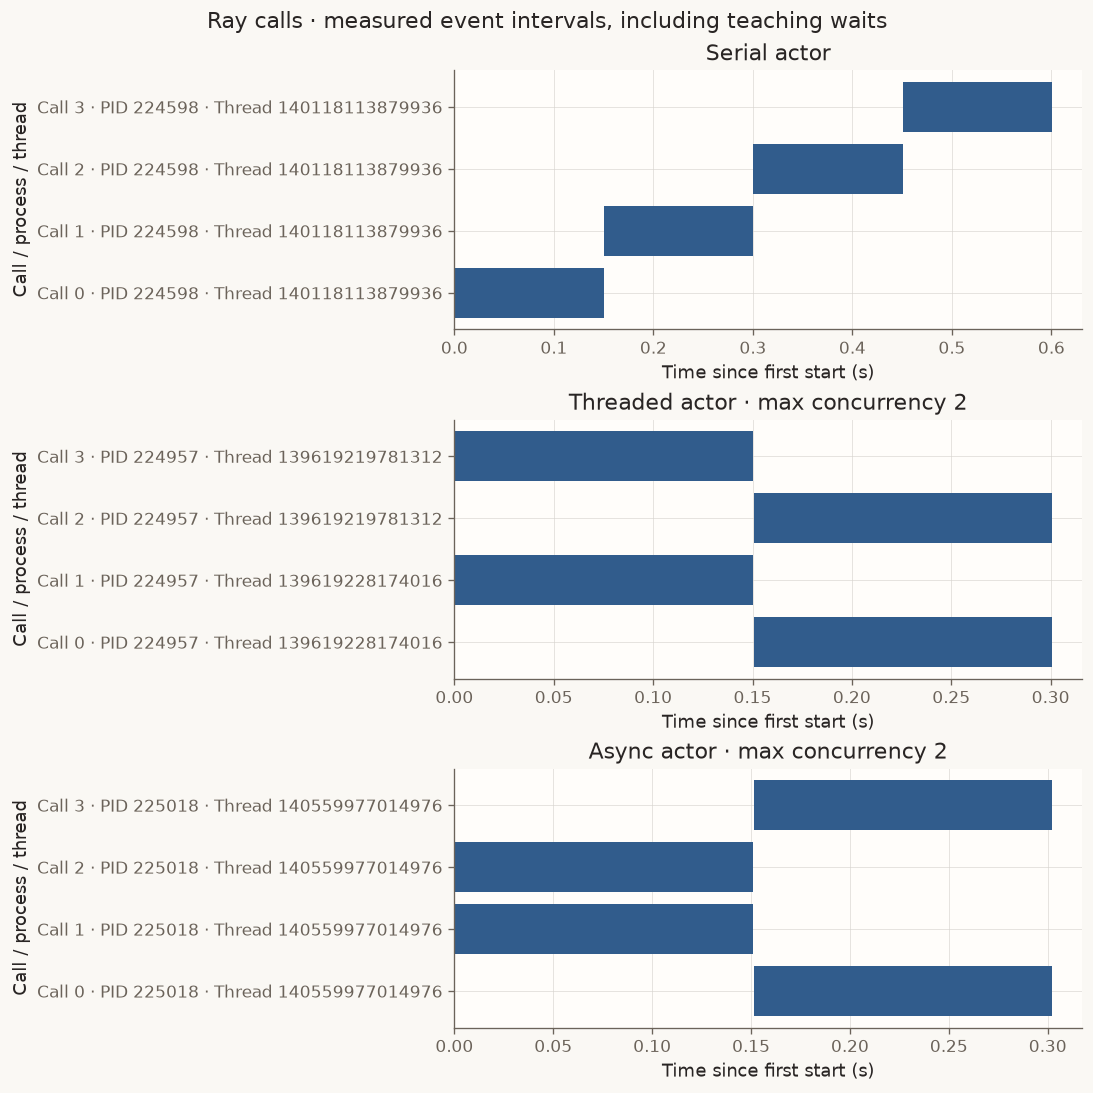

In [54]:
with observe("actor_timeline"):
    show_timeline([("Serial actor", serial_results), ("Threaded actor · max concurrency 2", threaded_results),
                   ("Async actor · max concurrency 2", async_results)], "actor-timeline")


**复述：** 分别用 PID、线程 ID、等待位置和共享状态解释三种结果。为什么这些数据不能说明线程提高了纯 Python 算力？

### 逻辑资源与后续连接

`num_cpus=1` 表达准入需求，不是绑定一个物理核或限制库只用一个线程。
本页 Actor 显式声明 CPU，避免默认 Actor 的历史资源规则干扰观察。
下面核查本运行时资源，再进入 GPU Notebook。[资源模型](https://docs.ray.io/en/latest/ray-core/scheduling/resources.html)


In [55]:
with observe("logical_resources") as step:
    step["resources"] = ray.cluster_resources()
    display({"ray_logical_resources": step["resources"],
             "host_cpu_count": run["environment"]["host_cpu_count"],
             "kernel_pid": os.getpid()})


{'ray_logical_resources': {'node:__internal_head__': 1.0,
  'memory': 366688923648.0,
  'node:10.128.0.2': 1.0,
  'object_store_memory': 134217728.0,
  'CPU': 4.0},
 'host_cpu_count': 96,
 'kernel_pid': 188846}

Ray 的 Task/Actor 负责执行编排；[NCCL](../../distributed-training/README.md)关注张量通信，
[vLLM](../../inference-serving/README.md)关注生成循环、请求和 KV 调度，
[verl](../../../paths/ai-infra/14-post-training-rlhf.md#ai-14-7)把后训练角色与这些执行机制组合。
这些是职责定位，尚未追踪特定版本代码。Ray Actor 是有状态进程机制，RL 中 actor 常指 policy 角色。


### 保存并清理进阶实验

先回答本页的观察问题，写下自己的解释和遗漏前提，再执行清理单元。步骤的 `passed` 表示该运行单元完成；会话的 `finished` 表示已保存并清理，不代表所有单元已执行或已经掌握。
重新开始一个完整实验时，重启 kernel 并从头运行，使用新的运行目录。


In [56]:
if owns_runtime:
    ray.shutdown()
    owns_runtime = False
run["status"] = "finished" if all(step["status"] == "passed" for step in run["steps"]) else "failed"
run["finished_at_utc"] = datetime.now(timezone.utc).isoformat()
save_record()
display({"status": run["status"], "record": str(RUN_DIR / "run.json")})


{'status': 'finished',
 'record': '/home/ubuntu/ai-infra-learning/.runs/ray-cpu/20261002T135810.072866Z/run.json'}

## 回收学习成果

保存 Notebook 的真实输出，把它和本轮 `.runs/ray-cpu/` 记录一起取回。服务器修改了讲解或代码时，先比较差异，再合并进主仓库。下例的 `gpu-box` 与服务器路径是占位示例，请替换成实际连接与路径：

```bash
mkdir -p .runs/from-ray-server
rsync -av gpu-box:~/ai-infra-learning/topics/distributed-runtime/ray/cpu.ipynb .runs/from-ray-server/
rsync -av gpu-box:~/ai-infra-learning/.runs/ray-cpu/ .runs/from-ray-server/ray-cpu/
```

精选小记录放主题 `results/`；绘图单元与 SVG 一起保存，Notebook 保留 PNG 输出。详细的理解过程留在本页，精选结论补到 [主题入口](README.md)，仍未解决的问题进入 [GAPS](../../../GAPS.md)。

- **我的解释：** 待学习者填写。
- **预测与实际观察的差别：** 已保存代码验证输出，学习者自己的预测与解释待填写。
- **仍然无法解释的地方：** 待填写。

## 来源、改编范围与修正

主材料：Max Pumperla、Edward Oakes、Richard Liaw，[《Learning Ray》公开版第 2 章](https://maxpumperla.com/learning_ray/ch_02_ray_core/)。改编依据为作者公开仓库的 [ch_02_ray_core.ipynb](https://github.com/maxpumperla/learning_ray/blob/321ebe5fdab451f75f2736683fd40921feffdf27/notebooks/ch_02_ray_core.ipynb)，来源提交 `321ebe5fdab451f75f2736683fd40921feffdf27`，原示例安装 Ray 2.2.0。已阅读其中 A Ray Core Intro 的讲解与代码；系统内部、故障恢复和 MapReduce 不在本次改编范围。版权与 MIT 许可保留在主题的 `LICENSE.learning-ray.txt`，此许可针对公开仓库内容，不延伸到出版书全文。

| 本页位置 | 对应原章 | 本仓库的改动 |
| --- | --- | --- |
| 普通读取与任务提交 | Your First Ray API Example、Ray Tasks | 保留列表模拟读取；拆开定义、提交、引用和取值，增加注释与等待对照 |
| 数据共享与已就绪结果 | The Object Store、Non-blocking calls | 补普通值与引用传参对照；修正超时语义 |
| 任务依赖 | Task dependencies | 用大写转换替代相邻记录查询，保持依赖机制 |
| 跨调用保留状态 | Ray Actors | 先给普通类，再远程化；显式等待每次计数更新 |
| 四道练习的题目、TODO 与测试，可选进阶 | 本仓库补充 | 练习实现由学习者填写，测试检查结果与接口约定；进阶实验沿用此前官方文档示例组织 |

辅助对照：[官方 Gentle Introduction](https://docs.ray.io/en/latest/ray-core/examples/gentle_walkthrough.html)。它也是原书案例的简化版，用于交叉检查，不作为独立覆盖更多主题的教材。

技术核查日期：**2026-10-02**。本地目标版本为 **Ray 2.59.0**；`latest` 文档会变化，应同时保留运行记录中的实际版本。

- [Tasks](https://docs.ray.io/en/latest/ray-core/tasks.html)：远程函数、任务提交和结果获取。
- [Objects](https://docs.ray.io/en/latest/ray-core/objects.html)、[重复大参数](https://docs.ray.io/en/latest/ray-core/patterns/pass-large-arg-by-value.html)：顶层引用参数、不可变对象与数据复用。
- [Actors](https://docs.ray.io/en/latest/ray-core/actors.html)、[Actor 执行顺序](https://docs.ray.io/en/latest/ray-core/actors/task-orders.html)：实例状态、句柄与调用顺序边界。
- [`ray.wait`](https://docs.ray.io/en/latest/ray-core/api/doc/ray.wait.html)、[`ray.get`](https://docs.ray.io/en/latest/ray-core/api/doc/ray.get.html)：等待、返回值和超时，不把超时写成取消任务。
- [资源模型](https://docs.ray.io/en/latest/ray-core/scheduling/resources.html)：逻辑 CPU 准入与物理资源的区别。
- [Python 的 sleep](https://docs.python.org/3/library/time.html#time.sleep)：暂停调用线程。本页顺序等待由代码控制流造成，未把 sleep 当作 CPU 工作，也未沿用原文的 GIL 归因。

其他修正：不把原文的历史运行数字复制成当前结果；不把对象引用描述成零传输；依赖由 Ray 在任务执行前解析，不把简化解释写成内部必定调用 Python `ray.get` 的实现承诺。

[用户提供的视频](https://www.bilibili.com/video/BV1HuZcBEEyy/)仍仅核查过标题与简介；未读取正文、字幕和私有代码，不作为本页的改编来源。
